In [1]:
!pip install -q "numpy==1.26.4"

In [2]:
!pip install "transformer_lens==2.17.0"

In [3]:
import os
import json
import gc
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer
from pathlib import Path
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from collections import defaultdict
import warnings
import logging

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

PALETTE = {
    'genuine':   '#e74c3c',
    'stylistic': '#3498db',
    'before':    '#e67e22',
    'on':        '#9b59b6',
}

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

2026-05-18 21:25:30.651950: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779139530.879185     127 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779139530.945584     127 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779139531.512951     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779139531.512993     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779139531.512996     127 computation_placer.cc:177] computation placer alr

In [4]:
# ── configuration ───────────────────────────────────────────────
CLASSIFIED_FILE = '/kaggle/input/datasets/svvikhlyantseva/classified-corrections-expanded-context/classified_corrections_expanded_context.json'
SOURCE_FILE     = '/kaggle/input/datasets/svvikhlyantseva/merged-results/merged_results.json'
OUTPUT_DIR      = '/kaggle/working/logit_lens_output'
MODEL_NAME      = 'Qwen/Qwen3-8B'


# ── parameters ───────────────────────────────────────────────────
LAYERS_TO_PROBE = [8, 10, 12, 16, 20, 22, 24, 26, 28, 30, 32, 35]
PRIMARY_LAYER   = 30
MAX_TOKENS   = 256   # prompt truncation — keeps the end (closest to the marker)
RANDOM_SEED  = 42
# ────────────────────────────────────────────────────────────────

np.random.seed(RANDOM_SEED)
Path(OUTPUT_DIR).mkdir(exist_ok=True)

In [6]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────
# Focus only on "wait" marker, high confidence, both classes

def load_wait_cases(classified_file, source_file):
    """Load genuine_high and stylistic_high cases for 'wait' marker only."""
    with open(classified_file, 'r', encoding='utf-8') as f:
        classified = json.load(f)
    with open(source_file, 'r', encoding='utf-8') as f:
        source_data = json.load(f)

    src_lookup = {
        q['id']: q.get('question', '')
        for q in source_data.get('questions', [])
    }

    genuine_hc, stylistic_hc = [], []

    for q in classified.get('questions', []):
        q_id = q['id']
        for mb in q.get('markers', []):
            if mb['marker'] != 'wait':
                continue
            for cls in mb.get('classifications', []):
                if cls.get('confidence') != 'high':
                    continue
                case = {
                    'question_id'     : q_id,
                    'question_text'   : src_lookup.get(q_id, ''),
                    'marker'          : 'wait',
                    'occurrence_index': cls.get('occurrence_index', 1),
                    'classification'  : cls.get('classification', ''),
                    'context_before'  : cls.get('context_before', ''),
                    'context_after'   : cls.get('context_after', ''),
                    'reasoning'       : cls.get('reasoning', ''),
                }
                if cls['classification'] == 'genuine_correction':
                    genuine_hc.append(case)
                elif cls['classification'] == 'stylistic_filler':
                    stylistic_hc.append(case)

    print(f"wait / high-confidence — genuine: {len(genuine_hc)}, "
          f"stylistic: {len(stylistic_hc)}")
    return genuine_hc, stylistic_hc


genuine_hc, stylistic_hc = load_wait_cases(CLASSIFIED_FILE, SOURCE_FILE)

wait / high-confidence — genuine: 399, stylistic: 255


In [7]:
# ── 2. MODEL LOADING ────────────────────────────────────────────

def load_model():
    print(f"\nLoading model {MODEL_NAME}...")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    n_gpu  = torch.cuda.device_count()
    print(f"Device: {device}, GPUs: {n_gpu}")

    if n_gpu >= 2:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=None, n_devices=2,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            move_to_device=True, trust_remote_code=True,
        )
    else:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=device,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            trust_remote_code=True,
        )

    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    print(f"Model: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
    for i in range(n_gpu):
        print(f"GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.2f} GB")

    return model, tokenizer


model, tokenizer = load_model()


Loading model Qwen/Qwen3-8B...
Device: cuda, GPUs: 2


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer
Model: 36 layers, d_model=4096
GPU 0: 8.29 GB
GPU 1: 8.29 GB


In [8]:
# ── 3. ACTIVATION EXTRACTION ─────────────────────────────────────
# For each case: collect residual stream at EVERY target layer,
# at BOTH positions (before and on marker).
# This mirrors the SEAL paper's approach of comparing representations
# across the full set of target layers.

def build_token_ids(case, tokenizer, max_tokens):
    """Return (ids_before, ids_on) or (None, None) if context missing."""
    context_before = case.get('context_before', '')
    if not context_before:
        return None, None

    messages = [{"role": "user", "content": case['question_text']}]
    prefix   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    ) + "<think>\n"

    ids_before = tokenizer.encode(
        prefix + context_before
    )[-max_tokens:]
    ids_on     = tokenizer.encode(
        prefix + context_before + ' wait'
    )[-max_tokens:]

    if len(ids_before) < 5:
        return None, None
    return ids_before, ids_on


def extract_all_layers_both_positions(model, tokenizer, cases,
                                       layers, max_tokens, label=''):
    """
    For each case: extract residual stream at last token position
    for both before_marker and on_marker, at every target layer.
    
    Returns:
        before_acts: dict {layer: np.ndarray [n_cases, d_model]}
        on_acts:     dict {layer: np.ndarray [n_cases, d_model]}
    """
    before_acts = defaultdict(list)
    on_acts     = defaultdict(list)
    skipped     = 0

    print(f"\nExtracting [{label}] — {len(cases)} cases...")

    for i, case in enumerate(cases):
        ids_before, ids_on = build_token_ids(case, tokenizer, max_tokens)
        if ids_before is None:
            skipped += 1
            continue

        # single run_with_cache per position — collect all layers at once
        for pos_name, ids in [('before', ids_before), ('on', ids_on)]:
            inp = torch.tensor([ids], dtype=torch.long).to('cuda:0')
            with torch.no_grad():
                _, cache = model.run_with_cache(
                    inp,
                    names_filter=lambda n: 'hook_resid_post' in n
                )
            for layer in layers:
                key = f'blocks.{layer}.hook_resid_post'
                act = cache[key][0, -1, :].cpu().float().numpy()
                if pos_name == 'before':
                    before_acts[layer].append(act)
                else:
                    on_acts[layer].append(act)

            del cache
            torch.cuda.empty_cache()
            gc.collect()

        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(cases)}]")

    print(f"  Done: {len(before_acts[layers[0]])} extracted, {skipped} skipped")

    # stack into arrays
    before_out = {l: np.vstack(before_acts[l]) for l in layers
                  if before_acts[l]}
    on_out     = {l: np.vstack(on_acts[l])     for l in layers
                  if on_acts[l]}
    return before_out, on_out


# run extraction
g_before, g_on = extract_all_layers_both_positions(
    model, tokenizer, genuine_hc,
    LAYERS_TO_PROBE, MAX_TOKENS, 'genuine_high'
)
s_before, s_on = extract_all_layers_both_positions(
    model, tokenizer, stylistic_hc,
    LAYERS_TO_PROBE, MAX_TOKENS, 'stylistic_high'
)


Extracting [genuine_high] — 399 cases...
  [50/399]
  [100/399]
  [150/399]
  [200/399]
  [250/399]
  [300/399]
  [350/399]
  Done: 399 extracted, 0 skipped

Extracting [stylistic_high] — 255 cases...
  [50/255]
  [100/255]
  [150/255]
  [200/255]
  [250/255]
  Done: 255 extracted, 0 skipped


In [12]:
# ── 4. LINEAR PROBE PER LAYER × POSITION ─────────────────────────
# This is the core distinguishability test.
# For each (layer, position) pair: can a linear classifier separate
# genuine_high from stylistic_high activations?

def probe_one(g_vecs, s_vecs, label=''):
    """5-fold stratified LR probe. Returns dict with accuracy and gain."""
    if len(g_vecs) < 10 or len(s_vecs) < 10:
        return None

    X  = np.vstack([g_vecs, s_vecs])
    y  = np.array([1]*len(g_vecs) + [0]*len(s_vecs))
    sc = StandardScaler()
    Xs = sc.fit_transform(X)

    baseline = max(len(g_vecs), len(s_vecs)) / len(y)
    cv       = StratifiedKFold(n_splits=5, shuffle=True,
                                random_state=RANDOM_SEED)
    lr       = LogisticRegression(max_iter=1000, C=1.0,
                                   random_state=RANDOM_SEED)
    scores   = cross_val_score(lr, Xs, y, cv=cv, scoring='accuracy')

    # centroid cosine similarity — like SEAL paper
    mean_g   = g_vecs.mean(axis=0)
    mean_s   = s_vecs.mean(axis=0)
    centroid_sim = float(cosine_similarity(
        mean_g.reshape(1, -1), mean_s.reshape(1, -1)
    )[0, 0])

    return {
        'acc'         : scores.mean(),
        'std'         : scores.std(),
        'baseline'    : baseline,
        'gain'        : scores.mean() - baseline,
        'centroid_sim': centroid_sim,
        'n_genuine'   : len(g_vecs),
        'n_stylistic' : len(s_vecs),
    }

In [17]:
# collect results for both positions
results_before, results_on = {}, {}

print("\n" + "="*60)
print("LINEAR PROBE: genuine_high vs stylistic_high — wait only")
print("="*60)

for layer in LAYERS_TO_PROBE:
    for pos_name, g_dict, s_dict, res_dict in [
        ('BEFORE', g_before, s_before, results_before),
        ('ON',     g_on,     s_on,     results_on),
    ]:
        g_vecs = g_dict.get(layer)
        s_vecs = s_dict.get(layer)
        if g_vecs is None or s_vecs is None:
            continue
        r = probe_one(g_vecs, s_vecs,
                      label=f'layer {layer} / {pos_name}')
        if r:
            res_dict[layer] = r
            print(f"  Layer {layer:>3} [{pos_name:>6}]: "
                  f"acc={r['acc']:.3f}±{r['std']:.2f} "
                  f"gain={r['gain']:+.3f} "
                  f"cosine_sim={r['centroid_sim']:.4f}")


LINEAR PROBE: genuine_high vs stylistic_high — wait only
  Layer  16 [BEFORE]: acc=0.662±0.03 gain=+0.052 cosine_sim=0.9928
  Layer  16 [    ON]: acc=0.671±0.01 gain=+0.061 cosine_sim=0.9961
  Layer  20 [BEFORE]: acc=0.682±0.01 gain=+0.072 cosine_sim=0.9921
  Layer  20 [    ON]: acc=0.665±0.02 gain=+0.055 cosine_sim=0.9951
  Layer  22 [BEFORE]: acc=0.682±0.02 gain=+0.072 cosine_sim=0.9915
  Layer  22 [    ON]: acc=0.668±0.02 gain=+0.058 cosine_sim=0.9942
  Layer  24 [BEFORE]: acc=0.693±0.01 gain=+0.083 cosine_sim=0.9925
  Layer  24 [    ON]: acc=0.687±0.02 gain=+0.076 cosine_sim=0.9945
  Layer  26 [BEFORE]: acc=0.677±0.02 gain=+0.067 cosine_sim=0.9930
  Layer  26 [    ON]: acc=0.671±0.03 gain=+0.061 cosine_sim=0.9938
  Layer  28 [BEFORE]: acc=0.674±0.03 gain=+0.064 cosine_sim=0.9938
  Layer  28 [    ON]: acc=0.670±0.03 gain=+0.060 cosine_sim=0.9939
  Layer  30 [BEFORE]: acc=0.662±0.01 gain=+0.052 cosine_sim=0.9945
  Layer  30 [    ON]: acc=0.682±0.02 gain=+0.072 cosine_sim=0.9945
  La

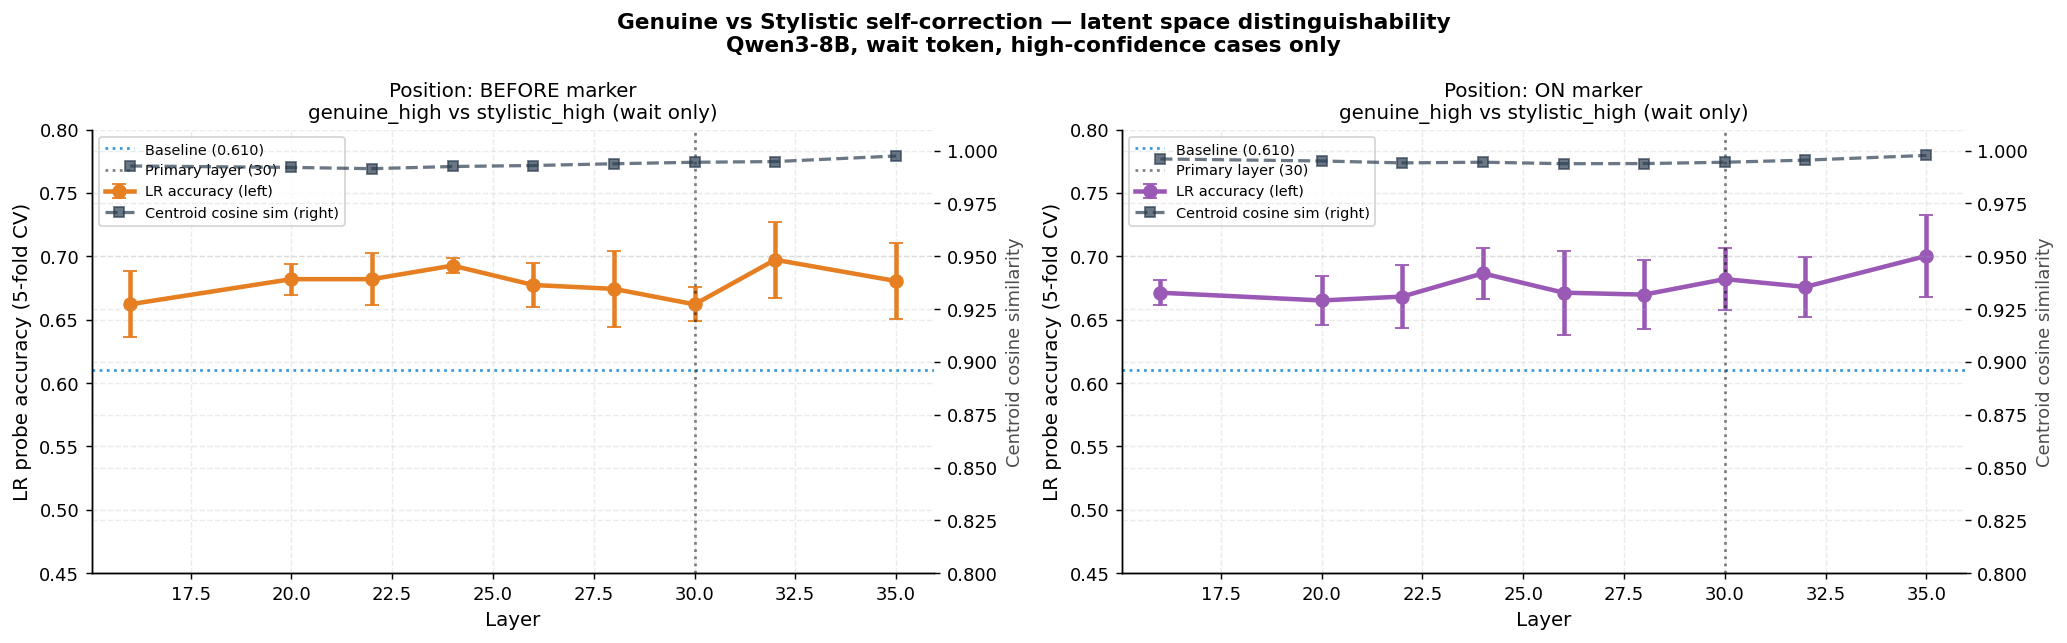

In [20]:
# ── 5. FIGURE: accuracy and centroid similarity across layers ─────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, res_dict, pos_name, color in [
    (axes[0], results_before, 'BEFORE marker', PALETTE['before']),
    (axes[1], results_on,     'ON marker',     PALETTE['on']),
]:
    layers_sorted = sorted(res_dict.keys())
    accs  = [res_dict[l]['acc']          for l in layers_sorted]
    stds  = [res_dict[l]['std']          for l in layers_sorted]
    sims  = [res_dict[l]['centroid_sim'] for l in layers_sorted]
    base  = res_dict[layers_sorted[0]]['baseline'] if layers_sorted else 0.5

    ax2 = ax.twinx()

    ax.errorbar(layers_sorted, accs, yerr=stds,
                color=color, marker='o', linewidth=2.5,
                capsize=4, markersize=7, label='LR accuracy (left)')
    ax2.plot(layers_sorted, sims,
             color='#2c3e50', linestyle='--', marker='s',
             linewidth=1.8, markersize=5, alpha=0.7,
             label='Centroid cosine sim (right)')

    ax.axhline(base, color=PALETTE['stylistic'], linestyle=':',
               linewidth=1.5, label=f'Baseline ({base:.3f})')
    ax.axvline(PRIMARY_LAYER, color='black', linestyle=':',
               alpha=0.5, label=f'Primary layer ({PRIMARY_LAYER})')

    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('LR probe accuracy (5-fold CV)', fontsize=11)
    ax2.set_ylabel('Centroid cosine similarity', fontsize=10, alpha=0.7)
    ax.set_title(
        f'Position: {pos_name}\n'
        f'genuine_high vs stylistic_high (wait only)',
        fontsize=11
    )
    ax.set_ylim(0.45, 0.80)
    ax2.set_ylim(0.80, 1.01)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle(
    'Genuine vs Stylistic self-correction — latent space distinguishability\n'
    'Qwen3-8B, wait token, high-confidence cases only',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/genuine_vs_stylistic_probe.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

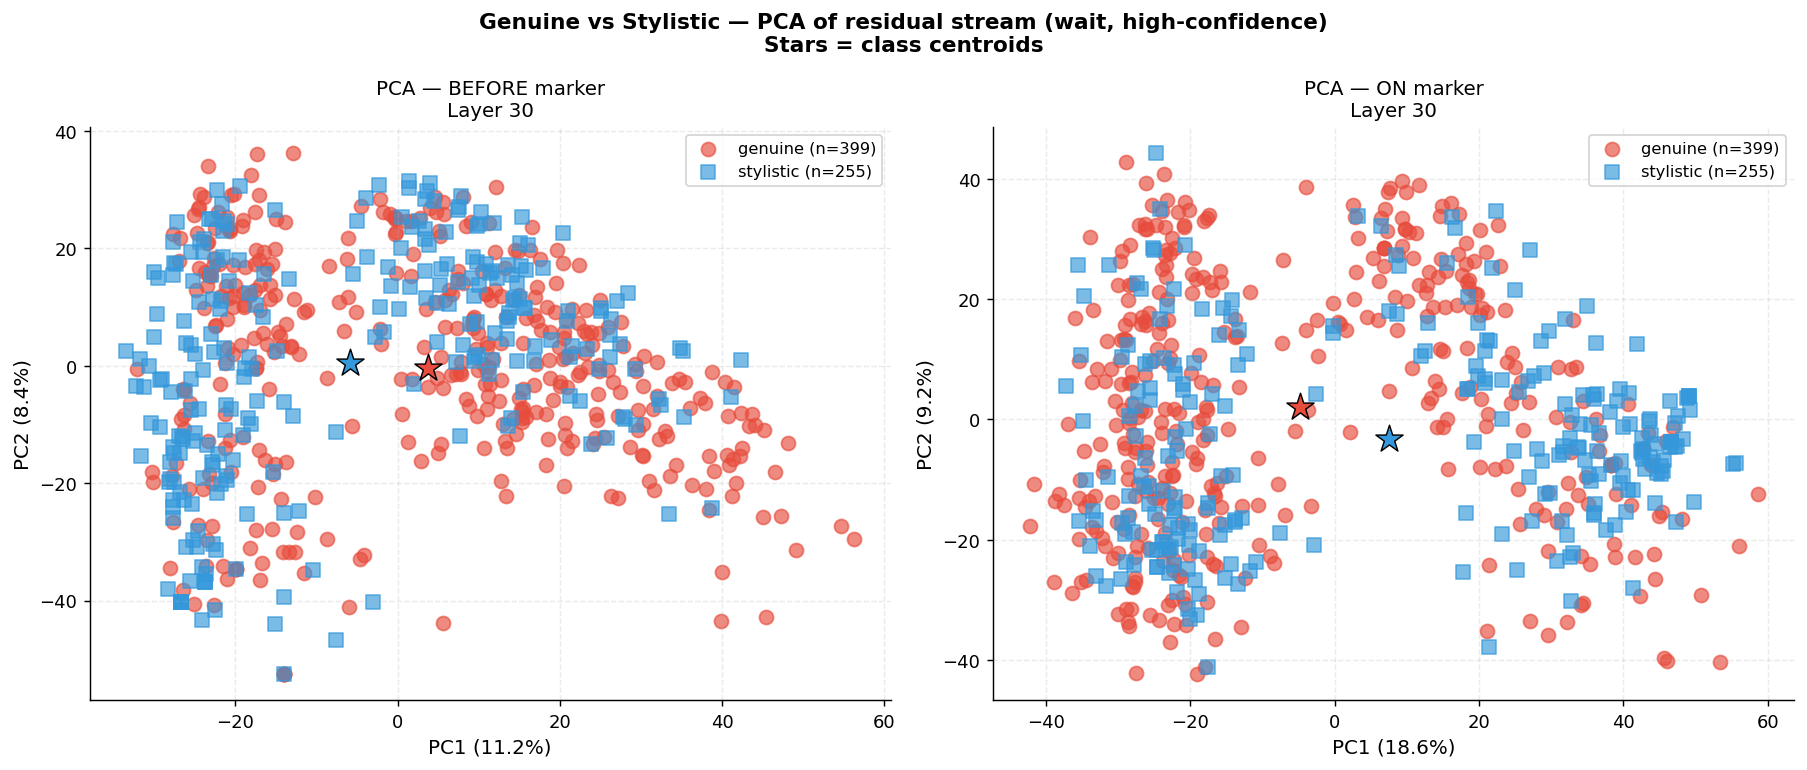

In [26]:
# ── 6. PCA AT PRIMARY LAYER — BOTH POSITIONS SIDE BY SIDE ────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, g_dict, s_dict, pos_name in [
    (axes[0], g_before, s_before, 'BEFORE marker'),
    (axes[1], g_on,     s_on,     'ON marker'),
]:
    g_vecs = g_dict.get(PRIMARY_LAYER)
    s_vecs = s_dict.get(PRIMARY_LAYER)
    if g_vecs is None or s_vecs is None:
        continue

    all_vecs = np.vstack([g_vecs, s_vecs])
    labels   = ['genuine']*len(g_vecs) + ['stylistic']*len(s_vecs)

    scaler = StandardScaler()
    scaled = scaler.fit_transform(all_vecs)
    pca    = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(scaled)
    v1, v2 = pca.explained_variance_ratio_[:2] * 100

    for lbl, color, marker_shape in [
        ('genuine',   PALETTE['genuine'],   'o'),
        ('stylistic', PALETTE['stylistic'], 's'),
    ]:
        idxs = [i for i, l in enumerate(labels) if l == lbl]
        ax.scatter(coords[idxs, 0], coords[idxs, 1],
                   c=color, marker=marker_shape,
                   alpha=0.65, s=60,
                   label=f'{lbl} (n={len(idxs)})')

    # centroid stars
    for lbl, color in [('genuine', PALETTE['genuine']),
                        ('stylistic', PALETTE['stylistic'])]:
        idxs = [i for i, l in enumerate(labels) if l == lbl]
        ax.scatter(coords[idxs, 0].mean(), coords[idxs, 1].mean(),
                   c=color, s=250, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=5)

    ax.set_xlabel(f'PC1 ({v1:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({v2:.1f}%)', fontsize=11)
    ax.set_title(f'PCA — {pos_name}\nLayer {PRIMARY_LAYER}', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    'Genuine vs Stylistic — PCA of residual stream (wait, high-confidence)\n'
    'Stars = class centroids',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/genuine_vs_stylistic_pca.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

In [15]:
# delta probe: on_activation minus before_activation
# this removes shared context signal
delta_g = {l: g_on[l] - g_before[l] for l in LAYERS_TO_PROBE
           if l in g_on and l in g_before}
delta_s = {l: s_on[l] - s_before[l] for l in LAYERS_TO_PROBE
           if l in s_on and l in s_before}

print("\nDelta probe (on minus before):")
for layer in LAYERS_TO_PROBE:
    g_delta = delta_g.get(layer)
    s_delta = delta_s.get(layer)
    if g_delta is None or s_delta is None:
        print(f"  Layer {layer:>3} [DELTA]: skipped (no data)")
        continue
    r = probe_one(g_delta, s_delta, label=f'delta layer {layer}')
    if r:
        print(f"  Layer {layer:>3} [DELTA]: "
              f"acc={r['acc']:.3f}±{r['std']:.2f} "
              f"gain={r['gain']:+.3f} "
              f"cosine_sim={r['centroid_sim']:.4f}")


Delta probe (on minus before):
  Layer   8 [DELTA]: acc=0.674±0.05 gain=+0.064 cosine_sim=0.9911
  Layer  10 [DELTA]: acc=0.671±0.03 gain=+0.061 cosine_sim=0.9909
  Layer  12 [DELTA]: acc=0.644±0.02 gain=+0.034 cosine_sim=0.9896
  Layer  16 [DELTA]: acc=0.668±0.03 gain=+0.058 cosine_sim=0.9865
  Layer  20 [DELTA]: acc=0.699±0.03 gain=+0.089 cosine_sim=0.9839
  Layer  22 [DELTA]: acc=0.688±0.03 gain=+0.078 cosine_sim=0.9867
  Layer  24 [DELTA]: acc=0.673±0.03 gain=+0.063 cosine_sim=0.9859
  Layer  26 [DELTA]: acc=0.679±0.04 gain=+0.069 cosine_sim=0.9853
  Layer  28 [DELTA]: acc=0.670±0.03 gain=+0.060 cosine_sim=0.9857
  Layer  30 [DELTA]: acc=0.665±0.03 gain=+0.055 cosine_sim=0.9854
  Layer  32 [DELTA]: acc=0.684±0.02 gain=+0.073 cosine_sim=0.9824
  Layer  35 [DELTA]: acc=0.682±0.03 gain=+0.072 cosine_sim=0.9787


In [22]:
# ── 7. SUMMARY TABLE ─────────────────────────────────────────────

print("\n" + "="*65)
print("SUMMARY: genuine_high vs stylistic_high (wait, high-confidence)")
print("="*65)
print(f"  {'Layer':>5}  {'BEFORE acc':>10}  {'BEFORE sim':>10}"
      f"  {'ON acc':>8}  {'ON sim':>8}  {'baseline':>8}")
print("  " + "-"*60)
for layer in sorted(set(list(results_before.keys())
                         + list(results_on.keys()))):
    rb = results_before.get(layer)
    ro = results_on.get(layer)
    base = (rb or ro)['baseline']
    b_acc = f"{rb['acc']:.3f}" if rb else " N/A "
    b_sim = f"{rb['centroid_sim']:.4f}" if rb else "  N/A "
    o_acc = f"{ro['acc']:.3f}" if ro else " N/A "
    o_sim = f"{ro['centroid_sim']:.4f}" if ro else "  N/A "
    print(f"  {layer:>5}  {b_acc:>10}  {b_sim:>10}"
          f"  {o_acc:>8}  {o_sim:>8}  {base:>8.3f}")

# find best layer+position
best = None
for layer, r in {**{(l,'before'): v for l,v in results_before.items()},
                  **{(l,'on'): v for l,v in results_on.items()}}.items():
    if best is None or r['acc'] > best['acc']:
        best = {'layer': layer[0], 'pos': layer[1], **r}
if best:
    print(f"\n  Best: layer={best['layer']} pos={best['pos']}"
          f" acc={best['acc']:.3f} gain={best['gain']:+.3f}")


SUMMARY: genuine_high vs stylistic_high (wait, high-confidence)
  Layer  BEFORE acc  BEFORE sim    ON acc    ON sim  baseline
  ------------------------------------------------------------
     16       0.662      0.9928     0.671    0.9961     0.610
     20       0.682      0.9921     0.665    0.9951     0.610
     22       0.682      0.9915     0.668    0.9942     0.610
     24       0.693      0.9925     0.687    0.9945     0.610
     26       0.677      0.9930     0.671    0.9938     0.610
     28       0.674      0.9938     0.670    0.9939     0.610
     30       0.662      0.9945     0.682    0.9945     0.610
     32       0.697      0.9948     0.676    0.9955     0.610
     35       0.680      0.9975     0.700    0.9977     0.610

  Best: layer=35 pos=on acc=0.700 gain=+0.090


In [13]:
# ── PROBE BY CATEGORY ─────────────────────────────────────────────
# Test whether genuine/stylistic distinction is stronger
# within specific question categories.

# first attach category to every case
with open(CLASSIFIED_FILE, 'r', encoding='utf-8') as f:
    clf_data = json.load(f)
cat_lookup = {q['id']: q.get('category', 'unknown')
              for q in clf_data.get('questions', [])}

for case in genuine_hc + stylistic_hc:
    case['category'] = cat_lookup.get(case['question_id'], 'unknown')

categories = ['math_trick', 'conflicting', 'ambiguous']

print("\n" + "="*65)
print("PROBE BY CATEGORY — layer 32, BEFORE position")
print("="*65)

for cat in categories:
    g_cat = [c for c in genuine_hc   if c.get('category') == cat]
    s_cat = [c for c in stylistic_hc if c.get('category') == cat]
    print(f"\n  {cat}: genuine={len(g_cat)}, stylistic={len(s_cat)}")

    if len(g_cat) < 10 or len(s_cat) < 10:
        print("    Not enough data for probing.")
        continue

    g_ids = {(c['question_id'], c['occurrence_index']): i
             for i, c in enumerate(genuine_hc)}
    s_ids = {(c['question_id'], c['occurrence_index']): i
             for i, c in enumerate(stylistic_hc)}

    for layer in [24, 28, 32, 35]:
        if layer not in g_before or layer not in s_before:
            continue

        # filter activations to this category
        g_cat_idxs = [g_ids[(c['question_id'], c['occurrence_index'])]
                      for c in g_cat
                      if (c['question_id'], c['occurrence_index']) in g_ids]
        s_cat_idxs = [s_ids[(c['question_id'], c['occurrence_index'])]
                      for c in s_cat
                      if (c['question_id'], c['occurrence_index']) in s_ids]

        g_vecs_cat = g_before[layer][g_cat_idxs] if g_cat_idxs else None
        s_vecs_cat = s_before[layer][s_cat_idxs] if s_cat_idxs else None

        r = probe_one(g_vecs_cat, s_vecs_cat)
        if r:
            print(f"    Layer {layer} [BEFORE]: "
                  f"acc={r['acc']:.3f} gain={r['gain']:+.3f} "
                  f"sim={r['centroid_sim']:.4f}")


PROBE BY CATEGORY — layer 32, BEFORE position

  math_trick: genuine=231, stylistic=117
    Layer 24 [BEFORE]: acc=0.724 gain=+0.060 sim=0.9902
    Layer 28 [BEFORE]: acc=0.710 gain=+0.046 sim=0.9921
    Layer 32 [BEFORE]: acc=0.704 gain=+0.040 sim=0.9935
    Layer 35 [BEFORE]: acc=0.701 gain=+0.037 sim=0.9972

  conflicting: genuine=89, stylistic=24
    Layer 24 [BEFORE]: acc=0.707 gain=-0.080 sim=0.9956
    Layer 28 [BEFORE]: acc=0.715 gain=-0.072 sim=0.9956
    Layer 32 [BEFORE]: acc=0.734 gain=-0.054 sim=0.9957
    Layer 35 [BEFORE]: acc=0.699 gain=-0.089 sim=0.9977

  ambiguous: genuine=79, stylistic=114
    Layer 24 [BEFORE]: acc=0.669 gain=+0.078 sim=0.9946
    Layer 28 [BEFORE]: acc=0.653 gain=+0.063 sim=0.9951
    Layer 32 [BEFORE]: acc=0.638 gain=+0.047 sim=0.9958
    Layer 35 [BEFORE]: acc=0.663 gain=+0.073 sim=0.9981


In [17]:
# ── PROBE BY CATEGORY ─────────────────────────────────────────────
# Test whether genuine/stylistic distinction is stronger
# within specific question categories.

# first attach category to every case
with open(CLASSIFIED_FILE, 'r', encoding='utf-8') as f:
    clf_data = json.load(f)
cat_lookup = {q['id']: q.get('category', 'unknown')
              for q in clf_data.get('questions', [])}

for case in genuine_hc + stylistic_hc:
    case['category'] = cat_lookup.get(case['question_id'], 'unknown')

categories = ['math_trick', 'conflicting', 'ambiguous']

print("\n" + "="*65)
print("PROBE BY CATEGORY — BOTH POSITIONS")
print("="*65)

for cat in categories:
    g_cat_cases = [c for c in genuine_hc   if c.get('category') == cat]
    s_cat_cases = [c for c in stylistic_hc if c.get('category') == cat]
    n_g = len(g_cat_cases)
    n_s = len(s_cat_cases)
    baseline_cat = max(n_g, n_s) / (n_g + n_s) if (n_g + n_s) > 0 else 0
    print(f"\n  {cat}: genuine={n_g}, stylistic={n_s}, "
          f"baseline={baseline_cat:.3f}")

    if n_g < 10 or n_s < 10:
        print("    Not enough data.")
        continue

    # get indices in the full arrays
    g_ids = {(c['question_id'], c['occurrence_index']): i
             for i, c in enumerate(genuine_hc)}
    s_ids = {(c['question_id'], c['occurrence_index']): i
             for i, c in enumerate(stylistic_hc)}

    g_cat_idxs = [g_ids[(c['question_id'], c['occurrence_index'])]
                  for c in g_cat_cases
                  if (c['question_id'], c['occurrence_index']) in g_ids]
    s_cat_idxs = [s_ids[(c['question_id'], c['occurrence_index'])]
                  for c in s_cat_cases
                  if (c['question_id'], c['occurrence_index']) in s_ids]

    for layer in [20, 24, 28, 32, 35]:
        for pos_name, acts_g, acts_s in [
            ('BEFORE', g_before, s_before),
            ('ON',     g_on,     s_on),
            ('DELTA',  delta_g,  delta_s),
        ]:
            gv = acts_g.get(layer)
            sv = acts_s.get(layer)
            if gv is None or sv is None:
                continue
            gv_cat = gv[g_cat_idxs]
            sv_cat = sv[s_cat_idxs]

            # use balanced class weights to fix imbalance issue
            from sklearn.linear_model import LogisticRegression
            from sklearn.preprocessing import StandardScaler
            from sklearn.model_selection import StratifiedKFold, cross_val_score
            X  = np.vstack([gv_cat, sv_cat])
            y  = np.array([1]*len(gv_cat) + [0]*len(sv_cat))
            Xs = StandardScaler().fit_transform(X)
            cv = StratifiedKFold(n_splits=5, shuffle=True,
                                  random_state=RANDOM_SEED)
            # class_weight='balanced' fixes the conflicting imbalance
            lr = LogisticRegression(max_iter=1000, C=1.0,
                                     class_weight='balanced',
                                     random_state=RANDOM_SEED)
            scores = cross_val_score(lr, Xs, y, cv=cv,
                                      scoring='balanced_accuracy')
            sim = float(cosine_similarity(
                gv_cat.mean(0).reshape(1,-1),
                sv_cat.mean(0).reshape(1,-1)
            )[0,0])
            print(f"    L{layer} [{pos_name:>5}]: "
                  f"bal_acc={scores.mean():.3f}±{scores.std():.2f} "
                  f"sim={sim:.4f}")


PROBE BY CATEGORY — BOTH POSITIONS

  math_trick: genuine=231, stylistic=117, baseline=0.664
    L20 [BEFORE]: bal_acc=0.677±0.08 sim=0.9875
    L20 [   ON]: bal_acc=0.671±0.07 sim=0.9944
    L20 [DELTA]: bal_acc=0.694±0.07 sim=0.9728
    L24 [BEFORE]: bal_acc=0.707±0.05 sim=0.9902
    L24 [   ON]: bal_acc=0.692±0.05 sim=0.9954
    L24 [DELTA]: bal_acc=0.681±0.09 sim=0.9765
    L28 [BEFORE]: bal_acc=0.673±0.06 sim=0.9921
    L28 [   ON]: bal_acc=0.641±0.03 sim=0.9956
    L28 [DELTA]: bal_acc=0.684±0.07 sim=0.9755
    L32 [BEFORE]: bal_acc=0.658±0.03 sim=0.9935
    L32 [   ON]: bal_acc=0.665±0.04 sim=0.9965
    L32 [DELTA]: bal_acc=0.681±0.04 sim=0.9759
    L35 [BEFORE]: bal_acc=0.654±0.04 sim=0.9972
    L35 [   ON]: bal_acc=0.686±0.03 sim=0.9982
    L35 [DELTA]: bal_acc=0.662±0.04 sim=0.9829

  conflicting: genuine=89, stylistic=24, baseline=0.788
    L20 [BEFORE]: bal_acc=0.503±0.07 sim=0.9943
    L20 [   ON]: bal_acc=0.506±0.05 sim=0.9974
    L20 [DELTA]: bal_acc=0.515±0.06 sim=0.98

In [37]:
# ── LOAD DoM VECTORS FROM MAIN NOTEBOOK ──────────────────────────

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# load saved vectors from main notebook
saved = np.load(
    '/kaggle/input/datasets/svvikhlyantseva/updated-correction-vectors-all-methods/correction_vectors_all_methods (1).npz'
)

# old vector: raw mean from original extraction
sv_old_raw = saved['mean_raw']           # [d_model]
sv_old     = sv_old_raw / np.linalg.norm(sv_old_raw)

# new DoM vectors per layer — saved by the improved extraction code
dom_combined = saved.get('dom_combined')  # [n_layers, d_model] or None

STEERING_LAYER = 21   # from attribution patching

if dom_combined is not None:
    sv_new_raw = dom_combined[STEERING_LAYER]
    sv_new     = sv_new_raw / np.linalg.norm(sv_new_raw)

    sim = float(cosine_similarity(
        sv_old.reshape(1,-1), sv_new.reshape(1,-1)
    )[0,0])
    print(f"Cosine similarity old vs new DoM vector: {sim:.4f}")
    print(f"  > 0.95 → same direction, minimal difference expected")
    print(f"  < 0.85 → meaningfully different, worth testing")

Cosine similarity old vs new DoM vector: 0.5361
  > 0.95 → same direction, minimal difference expected
  < 0.85 → meaningfully different, worth testing


In [34]:
saved

NpzFile '/kaggle/input/datasets/svvikhlyantseva/updated-correction-vectors-all-methods/correction_vectors_all_methods (1).npz' with keys: dom_before, dom_on, dom_combined, mean_raw, mean_error_cf

In [38]:
# ── 1. LOAD AIME 2025 AND MATCH TO YOUR QUESTIONS ────────────────

from datasets import load_dataset
import re

aime_ds = load_dataset("MathArena/aime_2025", split="train")

# build exact lookup: problem_text → answer (int)
aime_lookup = {}
for item in aime_ds:
    q_norm          = ' '.join(item['problem'].strip().split())
    aime_lookup[q_norm] = int(item['answer'])

print(f"AIME 2025: {len(aime_lookup)} problems")

# match your math_trick questions
with open(SOURCE_FILE, 'r', encoding='utf-8') as f:
    source = json.load(f)

GROUND_TRUTH = {}  # {question_id: int answer}

for q in source['questions']:
    if q.get('category') != 'math_trick':
        continue
    q_id   = q['id']
    q_norm = ' '.join(q['question'].strip().split())
    if q_norm in aime_lookup:
        GROUND_TRUTH[q_id] = aime_lookup[q_norm]
        print(f"  Q{q_id}: matched → {GROUND_TRUTH[q_id]}")
    else:
        print(f"  Q{q_id}: NOT MATCHED")

math_questions = [
    q for q in source['questions']
    if q.get('category') == 'math_trick'
    and q['id'] in GROUND_TRUTH
]
print(f"\nMatched math questions: {len(math_questions)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/14.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30 [00:00<?, ? examples/s]

AIME 2025: 30 problems
  Q3: matched → 237
  Q4: matched → 19
  Q10: matched → 293
  Q12: matched → 204
  Q13: matched → 49
  Q19: matched → 588
  Q22: matched → 279
  Q23: matched → 16
  Q24: matched → 77
  Q29: matched → 106
  Q31: matched → 248
  Q38: matched → 113
  Q46: matched → 259
  Q49: matched → 62
  Q50: matched → 149
  Q53: matched → 510
  Q54: matched → 735
  Q55: matched → 504
  Q56: matched → 907
  Q58: matched → 81
  Q69: matched → 336
  Q70: matched → 104
  Q74: matched → 117
  Q76: matched → 468
  Q78: matched → 82
  Q82: matched → 240
  Q86: matched → 60
  Q89: matched → 70
  Q91: matched → 821
  Q96: matched → 610

Matched math questions: 30


In [41]:
# ── 2. CATEGORY-SPECIFIC STEERING VECTORS ────────────────────────
# D+ = genuine_high from math_trick only  → positive steering
# D- = stylistic_high from math_trick only → negative steering
#
# We use activations already extracted in g_before / s_before / g_on / s_on
# just filter by category index

# find which indices in genuine_hc / stylistic_hc are math_trick
g_math_idxs = [i for i, c in enumerate(genuine_hc)
               if c.get('category') == 'math_trick']
s_math_idxs = [i for i, c in enumerate(stylistic_hc)
               if c.get('category') == 'math_trick']

print(f"\nmath_trick genuine activations:   {len(g_math_idxs)}")
print(f"math_trick stylistic activations: {len(s_math_idxs)}")

# DoM at STEERING_LAYER using only math_trick cases
# D+ mean = mean of genuine_high math activations ON marker
# D- mean = mean of stylistic_high math activations ON marker
# (ON marker is the marker itself — most direct signal)

g_math_acts = g_on[STEERING_LAYER][g_math_idxs]   # [n_g_math, d_model]
s_math_acts = s_on[STEERING_LAYER][s_math_idxs]   # [n_s_math, d_model]

mean_g_math = g_math_acts.mean(axis=0)  # [d_model]
mean_s_math = s_math_acts.mean(axis=0)  # [d_model]

# positive steering vector: D+ direction (genuine math corrections)
# subtract overall mean to remove general "being at this position" signal
overall_mean = np.vstack([g_math_acts, s_math_acts]).mean(axis=0)

sv_pos_raw = mean_g_math - overall_mean   # genuine direction
sv_neg_raw = mean_s_math - overall_mean   # stylistic direction

sv_pos = sv_pos_raw / (np.linalg.norm(sv_pos_raw) + 1e-8)
sv_neg = sv_neg_raw / (np.linalg.norm(sv_neg_raw) + 1e-8)

# random baseline
np.random.seed(RANDOM_SEED)
sv_rand = np.random.randn(model.cfg.d_model).astype(np.float32)
sv_rand = sv_rand / np.linalg.norm(sv_rand)

print(f"\nSteering vectors prepared (layer {STEERING_LAYER}):")
print(f"  sv_pos norm: {np.linalg.norm(sv_pos):.4f}")
print(f"  sv_neg norm: {np.linalg.norm(sv_neg):.4f}")
sim_pos_neg = float(cosine_similarity(
    sv_pos.reshape(1,-1), sv_neg.reshape(1,-1)
)[0,0])
print(f"  Cosine sim pos vs neg: {sim_pos_neg:.4f}")
print("  (negative → they point in opposite directions, good)")


math_trick genuine activations:   231
math_trick stylistic activations: 117

Steering vectors prepared (layer 20):
  sv_pos norm: 1.0000
  sv_neg norm: 1.0000
  Cosine sim pos vs neg: -1.0000
  (negative → they point in opposite directions, good)


In [52]:
# Variant B: proper DoM
# D+ = genuine math cases (on marker)
# D- = ALL stylistic high cases (on marker) — broader contrast set

# D+ already computed
# D- = all stylistic activations at steering layer
mean_s_all = s_on[STEERING_LAYER].mean(axis=0)   # all stylistic

sv_pos_raw = mean_g_math - mean_s_all
sv_neg_raw = mean_s_math - g_on[STEERING_LAYER].mean(axis=0)  # stylistic math vs all genuine

sv_pos = sv_pos_raw / (np.linalg.norm(sv_pos_raw) + 1e-8)
sv_neg = sv_neg_raw / (np.linalg.norm(sv_neg_raw) + 1e-8)

sim_pos_neg = float(cosine_similarity(
    sv_pos.reshape(1,-1), sv_neg.reshape(1,-1)
)[0,0])
print(f"Cosine sim pos vs neg: {sim_pos_neg:.4f}")
# now this will be something other than -1.0

Cosine sim pos vs neg: 0.5233


In [45]:
sv_pos

array([ 0.00018254,  0.00094648, -0.00412329, ...,  0.00506095,
       -0.01062419,  0.01030191], dtype=float32)

In [46]:
sv_neg

array([-0.00018254, -0.0009465 ,  0.00412327, ..., -0.00506095,
        0.01062418, -0.01030191], dtype=float32)

In [47]:
# ── 3. ACCURACY SCORING ──────────────────────────────────────────

def extract_numeric_answer(text):
    """Extract last integer from answer text — AIME format."""
    # look for boxed answer first
    boxed = re.findall(r'\\boxed\{(\d+)\}', text)
    if boxed:
        return int(boxed[-1])
    # fallback: last standalone integer
    nums = re.findall(r'\b(\d{1,4})\b', text.replace(',', ''))
    if nums:
        return int(nums[-1])
    return None


def score_aime(predicted, ground_truth):
    """Exact match on integer answer."""
    if predicted is None:
        return 0
    return int(int(predicted) == int(ground_truth))

In [50]:
def generate_natural(model, tokenizer, prompt_text,
                     steering_vector=None, coeff=0,
                     steering_layer=None,
                     max_new_tokens=2000,
                     stop_on_think_close=True):
    """
    Generate response letting the model close </think> naturally.
    No forced token injection — model decides when to stop thinking.
    
    steering_vector=None → baseline generation, no intervention
    coeff=0             → also baseline (hook does nothing)
    """
    messages = [{"role": "user", "content": prompt_text}]
    prefix   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    ) + "<think>\n"

    input_ids    = tokenizer.encode(prefix)[-256:]
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to('cuda:0')
    generated    = []

    # build hook only if actually steering
    hooks = []
    if steering_vector is not None and coeff != 0 and steering_layer is not None:
        layer_device = next(
            model.blocks[steering_layer].parameters()
        ).device
        sv_t      = torch.tensor(
            steering_vector, dtype=torch.float16
        ).to(layer_device)
        hook_name = f'blocks.{steering_layer}.hook_resid_post'

        def steering_hook(value, hook):
            value = value.clone()
            value[:, -1, :] = value[:, -1, :] + coeff * sv_t
            return value

        hooks = [(hook_name, steering_hook)]

    think_closed = False
    answer_start = None

    with torch.no_grad():
        current = input_tensor
        for step in range(max_new_tokens):
            if hooks:
                logits = model.run_with_hooks(current, fwd_hooks=hooks)
            else:
                logits = model(current)

            next_tok = torch.argmax(logits[0, -1, :]).item()
            generated.append(next_tok)

            next_t  = torch.tensor([[next_tok]], dtype=torch.long).to('cuda:0')
            current = torch.cat([current, next_t], dim=1)

            decoded_so_far = tokenizer.decode(generated)

            # detect when </think> appears — switch to answer mode
            if not think_closed and '</think>' in decoded_so_far:
                think_closed = True
                answer_start = len(generated)
                # after </think> we don't need steering anymore
                hooks = []

            # stop at EOS
            if next_tok == tokenizer.eos_token_id:
                break

            # optional: stop after answer is generated
            # (model generates \n\n or EOS after the answer)
            if think_closed and answer_start:
                answer_so_far = tokenizer.decode(
                    generated[answer_start:]
                )
                if len(answer_so_far) > 50 and answer_so_far.endswith('\n\n'):
                    break

    full_output = tokenizer.decode(generated)

    # split into thinking and answer
    if '</think>' in full_output:
        parts   = full_output.split('</think>', 1)
        thinking = parts[0]
        answer   = parts[1].strip()
    else:
        thinking = full_output
        answer   = ''

    return thinking, answer, think_closed

In [51]:
# ── 4. MAIN EXPERIMENT ───────────────────────────────────────────
# Three conditions per question:
#   A. Baseline    — no steering
#   B. Positive    — sv_pos (genuine math direction), coeff > 0
#   C. Negative    — sv_neg (stylistic math direction), coeff > 0
#      (subtracting stylistic = pushing away from unproductive pauses)

POS_COEFF = 100   # tune if needed — start conservative
NEG_COEFF = 100   # same scale

results_math = []

print("\n" + "="*65)
print(f"MATH ACCURACY EXPERIMENT  |  layer={STEERING_LAYER}")
print(f"  positive coeff={POS_COEFF}  negative coeff={NEG_COEFF}")
print("="*65)

for q in math_questions:
    q_id    = q['id']
    q_text  = q['question']
    gt      = GROUND_TRUTH[q_id]
    record  = {'question_id': q_id, 'ground_truth': gt,
               'question': q_text[:80], 'conditions': []}

    print(f"\nQ{q_id} | GT={gt}")
    print(f"  {q_text[:100]}...")

    for cond_name, sv, coeff in [
        ('baseline',  None,   0),
        ('positive',  sv_pos, POS_COEFF),
        ('negative',  sv_neg, NEG_COEFF),
    ]:
        torch.cuda.empty_cache()
        gc.collect()

        thinking, answer, think_closed = generate_natural(
            model, tokenizer, q_text,
            steering_vector=sv,
            coeff=coeff,
            steering_layer=STEERING_LAYER,
            max_new_tokens=2000,
        )

        n_think_tokens = len(tokenizer.encode(thinking))
        n_ans_tokens   = len(tokenizer.encode(answer))
        _, n_markers   = count_correction_markers(thinking)
        predicted      = extract_numeric_answer(answer)
        correct        = score_aime(predicted, gt)

        print(f"  [{cond_name:>8}] "
              f"think_tokens={n_think_tokens:>5} "
              f"markers={n_markers:>3} "
              f"predicted={str(predicted):>6} "
              f"correct={bool(correct)} "
              f"closed={think_closed}")
        if not think_closed:
            print(f"             ⚠ model did not close </think> in 2000 tokens")

        record['conditions'].append({
            'condition'     : cond_name,
            'coeff'         : coeff,
            'thinking'      : thinking,
            'answer'        : answer,
            'think_tokens'  : n_think_tokens,
            'answer_tokens' : n_ans_tokens,
            'markers'       : n_markers,
            'predicted'     : predicted,
            'correct'       : correct,
            'think_closed'  : think_closed,
        })

    results_math.append(record)

    # save after every question
    with open(f'{OUTPUT_DIR}/math_accuracy_results.json',
              'w', encoding='utf-8') as f:
        json.dump(results_math, f, ensure_ascii=False, indent=2)

print(f"\nSaved: {OUTPUT_DIR}/math_accuracy_results.json")


MATH ACCURACY EXPERIMENT  |  layer=20
  positive coeff=100  negative coeff=100

Q3 | GT=237
  Let $A$ be the set of positive integer divisors of $2025$. Let $B$ be a randomly selected subset of ...


KeyboardInterrupt: 